# Beyond Stoner-Wohlfarth inverse Single-grain easy axis model

This notebook showcases how to train ML surrogate models for predicting the extrinsic material properties from intrinsic ones for hard and soft magnetic materials. Namely, we predict A (J/m), K (J/m^3) and Ms (A/m) from Hc (A/m), Mr (A/m) and BHmax (J/m^3). 

In [12]:
import sys
sys.path.append("..") 

In [13]:
from scripts.analyze_magnetic_data import analyze_magnetic_data

shape before droping  12012
shape after droping nans 10388
Performing basic analysis...

Shape of the DataFrame: (10388, 7)
No missing values in the DataFrame.
Basic statistics:
           Ms (A/m)       A (J/m)     K (J/m^3)             D      Hc (A/m)  \
count  1.038800e+04  1.038800e+04  1.038800e+04  1.038800e+04  1.038800e+04   
mean   1.473733e+06  5.690394e-12  2.253615e+06  3.333333e-01  1.647912e+06   
std    1.040838e+06  3.045869e-12  2.392467e+06  5.551382e-17  1.899942e+06   
min    7.963789e+04  1.004906e-13  1.000306e+04  3.333333e-01  1.845141e-01   
25%    5.255267e+05  3.097769e-12  1.818041e+05  3.333333e-01  1.738620e+05   
50%    1.338793e+06  6.301445e-12  1.394237e+06  3.333333e-01  9.131228e+05   
75%    2.283393e+06  8.385093e-12  3.765290e+06  3.333333e-01  2.441022e+06   
max    3.966836e+06  9.999285e-12  9.931436e+06  3.333333e-01  7.951766e+06   
range  3.887198e+06  9.898794e-12  9.921433e+06  0.000000e+00  7.951766e+06   

           Mr (A/m)  BHmax (J/m

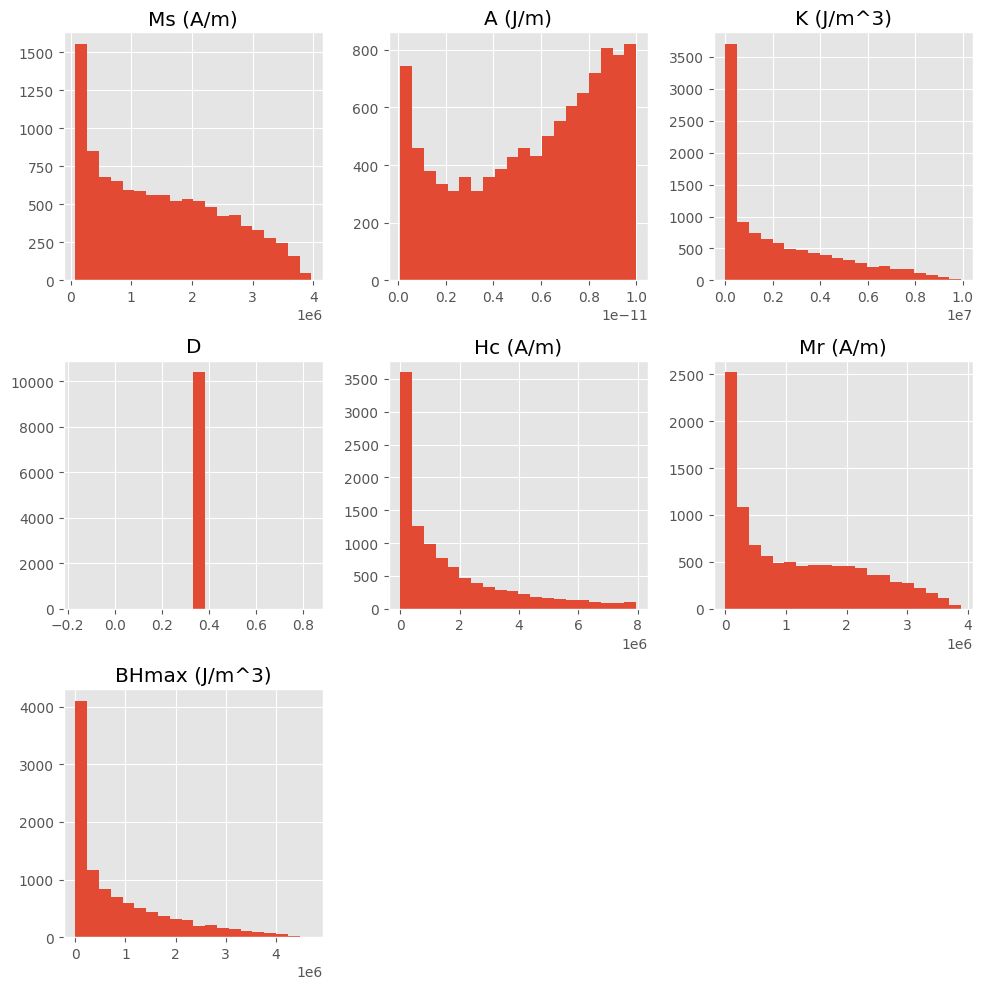

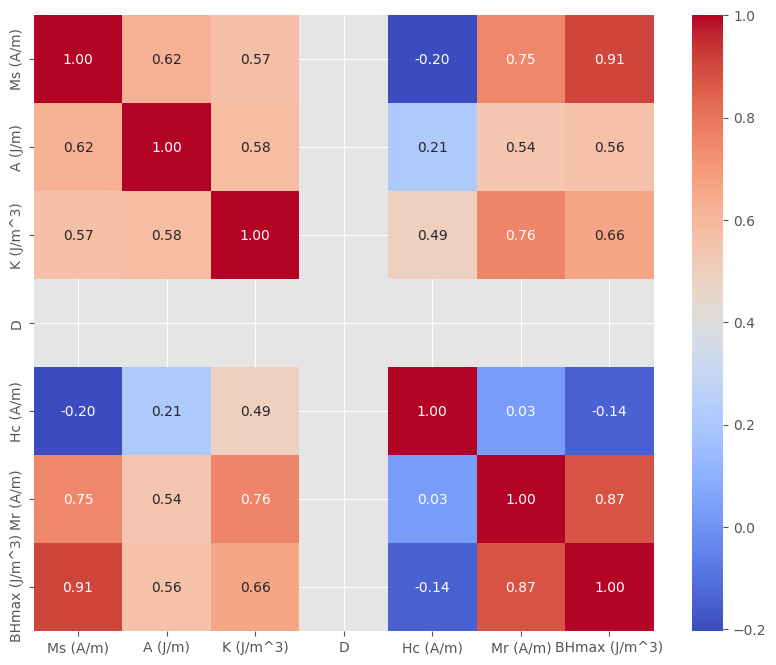

Done basic analysis..

3041986.392923244 3067036.410170976 0.991832500858268 0.991832500858268 1.2193368074540317e-09 1.1948959055522148e-09 1.0204544193249383
# Soft magnets: 5996 out of  10388


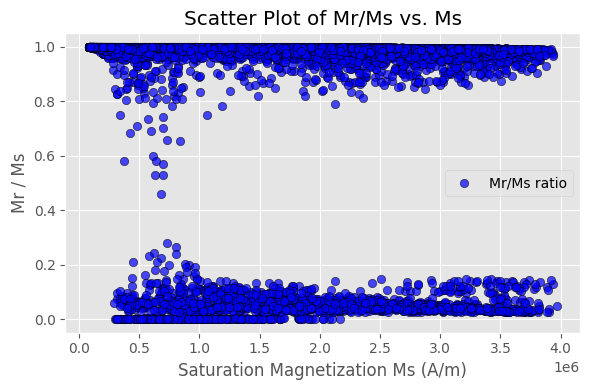

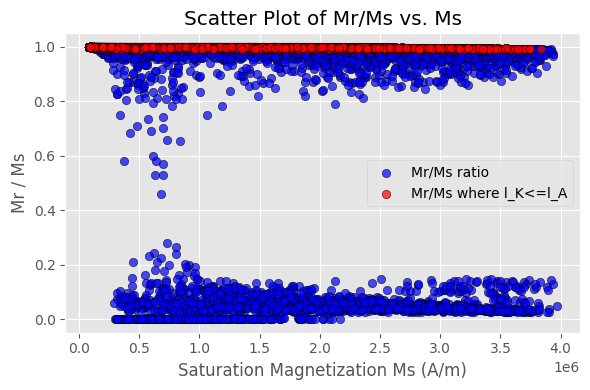

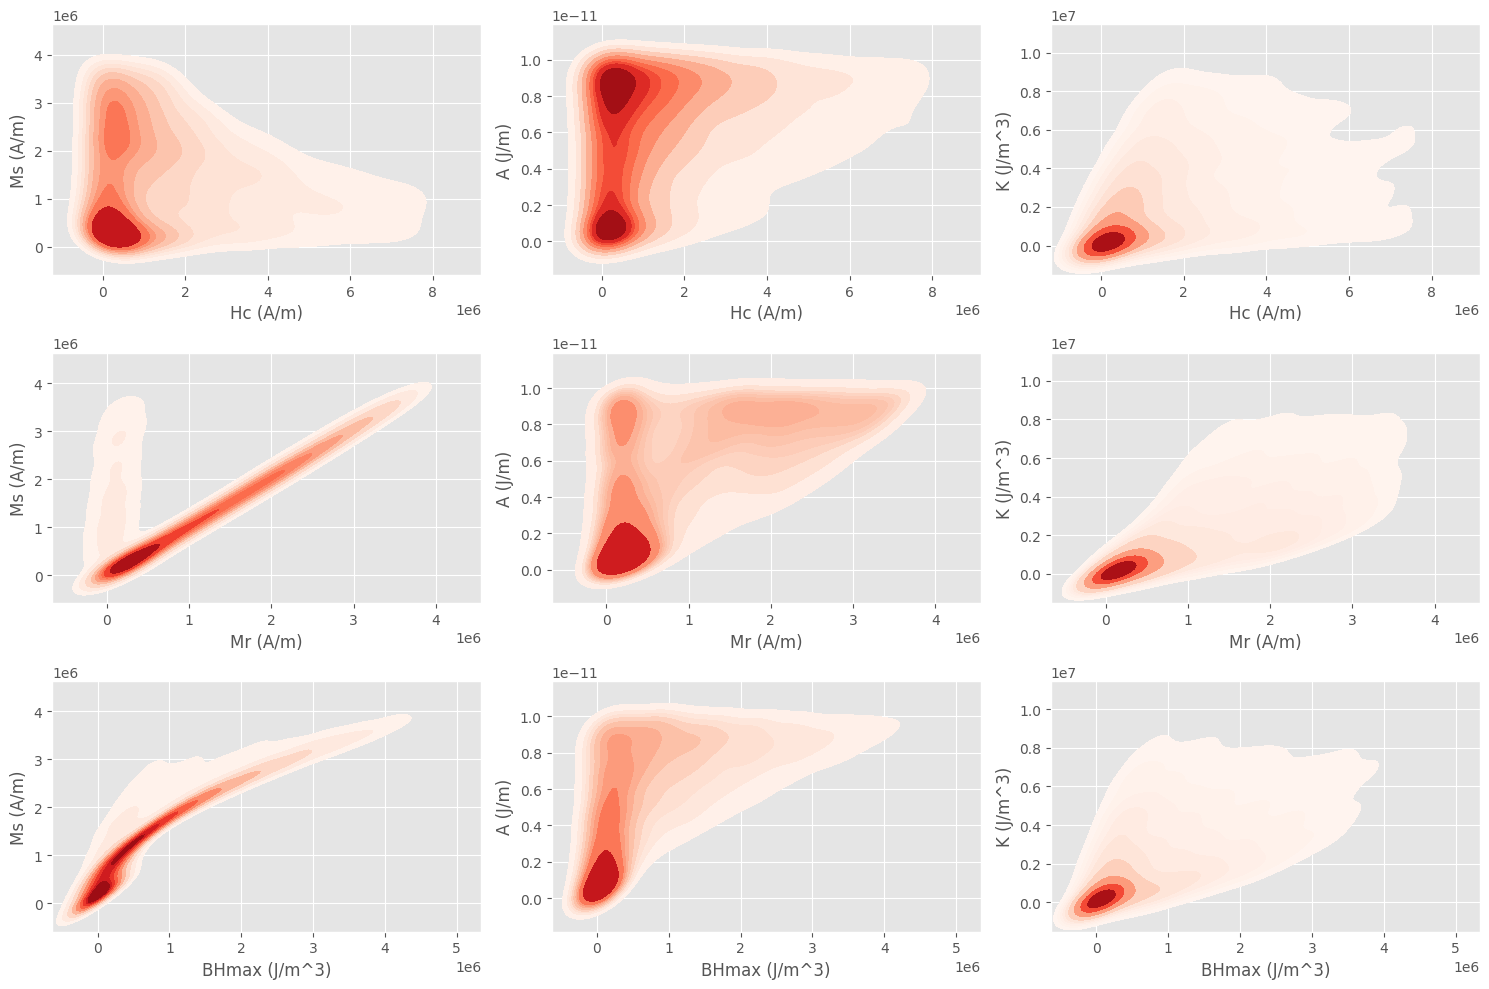

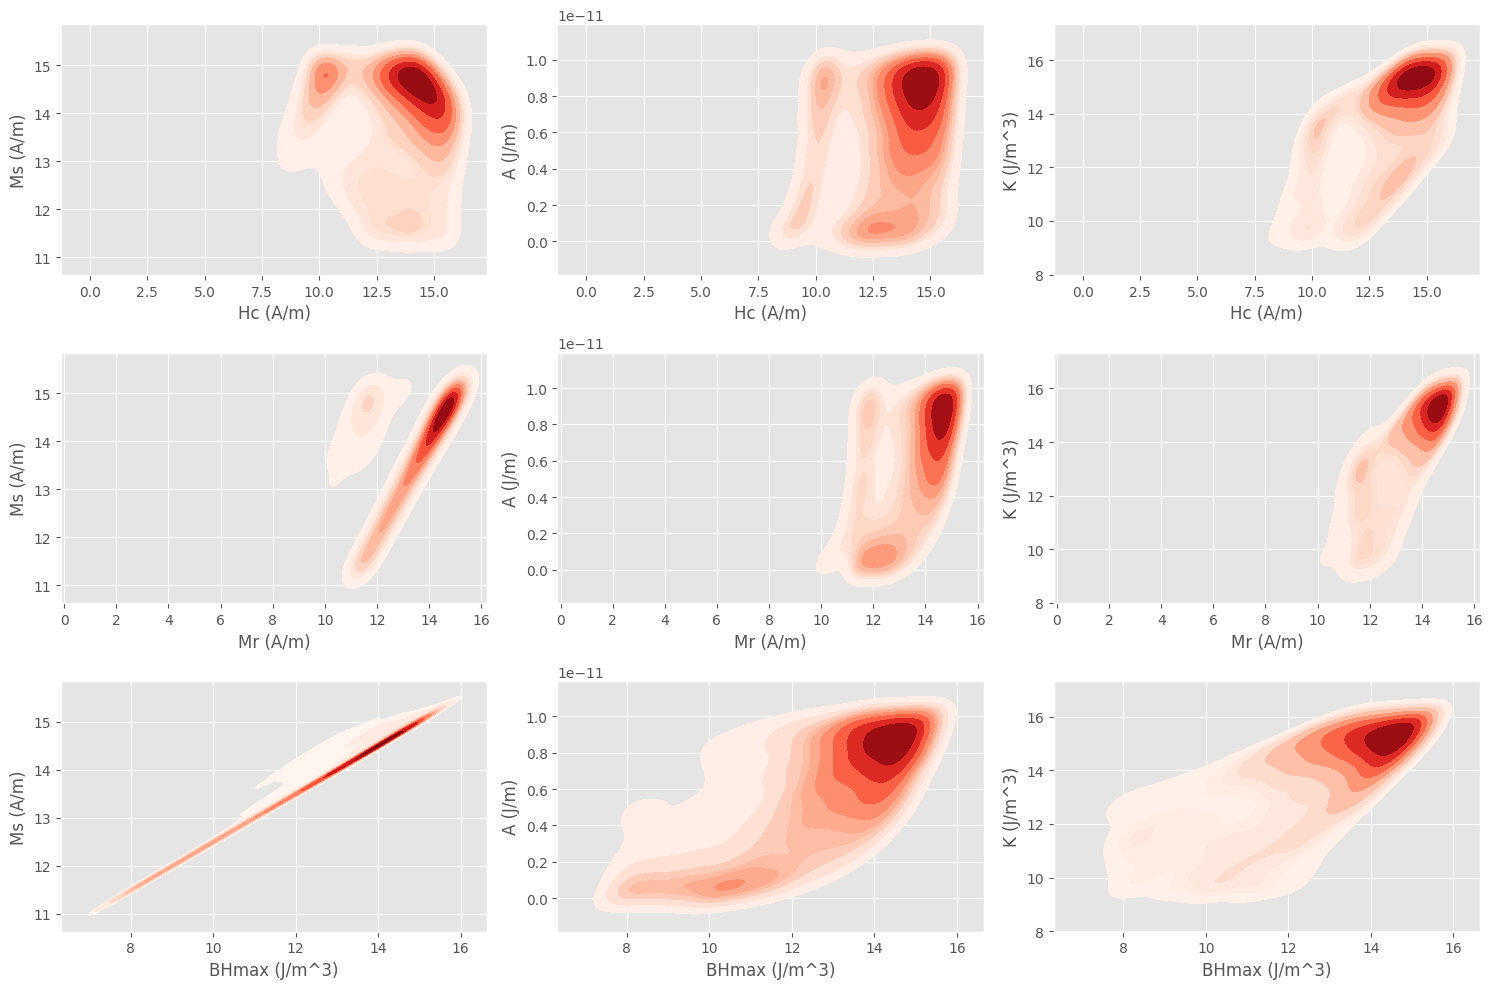

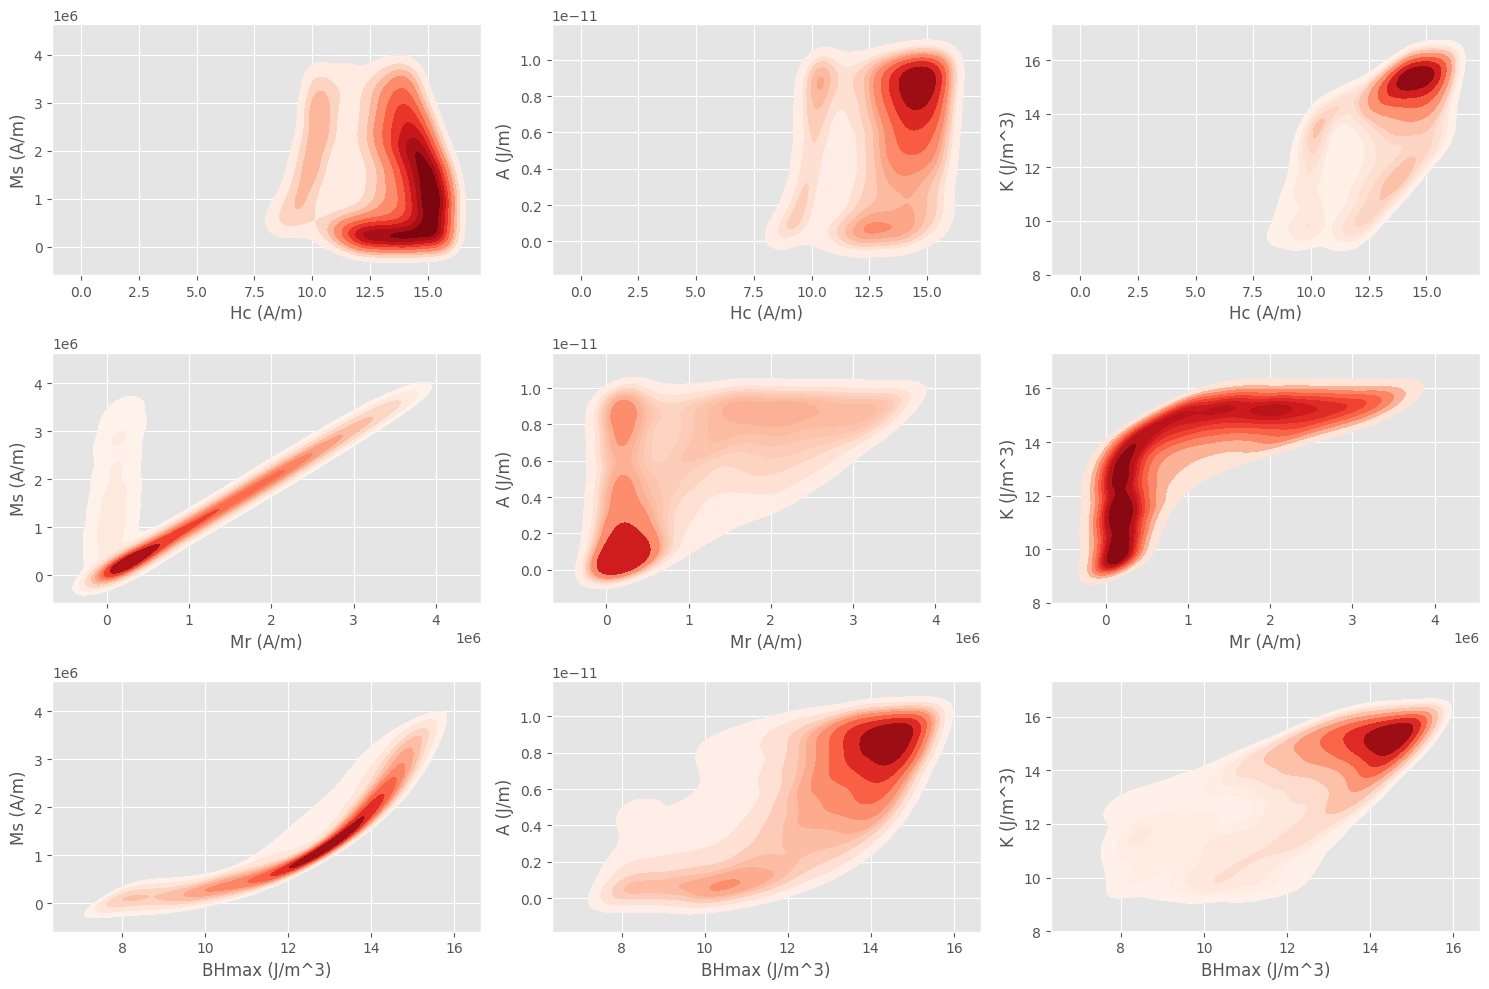

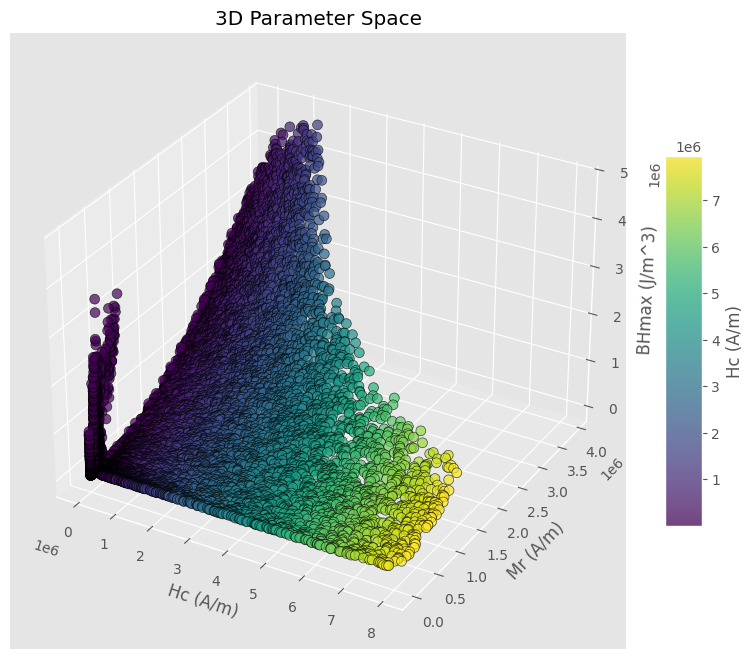




Performing clustering analysis for soft/hard magnets...


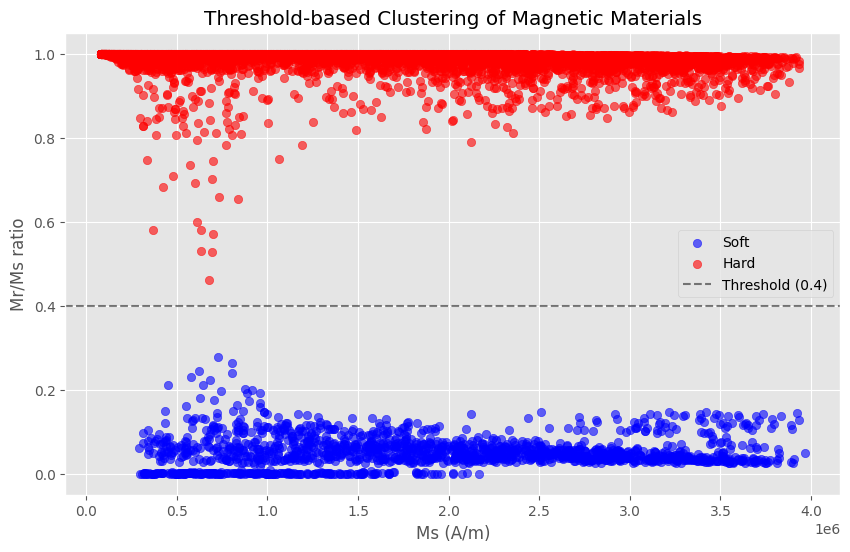


 Threshold clustering results:
Number of soft magnets:  1556
Number of hard magnets:  8832


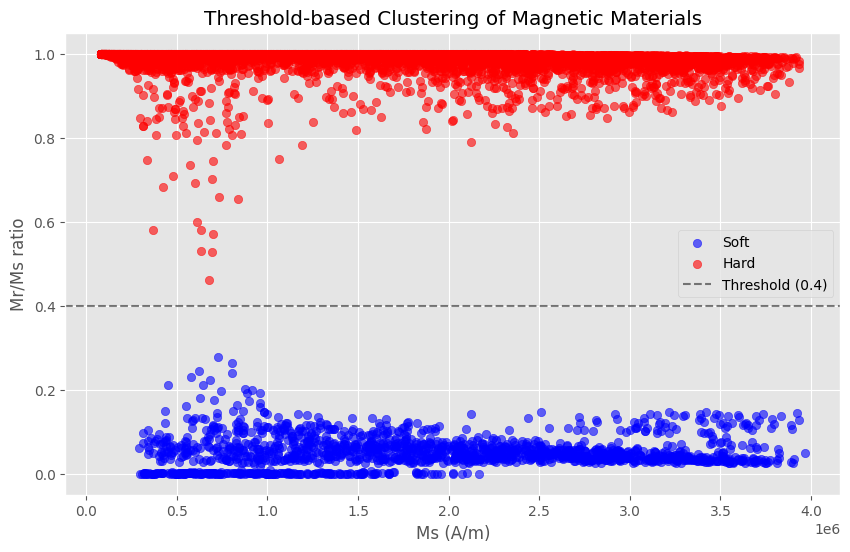

Training supervised classification model for hard/soft...
Best parameters: {'estimator__max_depth': 8}

Model Performance on Test Set:
Accuracy: 0.9995
Precision: 0.9994
Recall: 1.0000
F1 Score: 0.9997

Classification Report:
              precision    recall  f1-score   support

        Soft       1.00      1.00      1.00       311
        Hard       1.00      1.00      1.00      1767

    accuracy                           1.00      2078
   macro avg       1.00      1.00      1.00      2078
weighted avg       1.00      1.00      1.00      2078



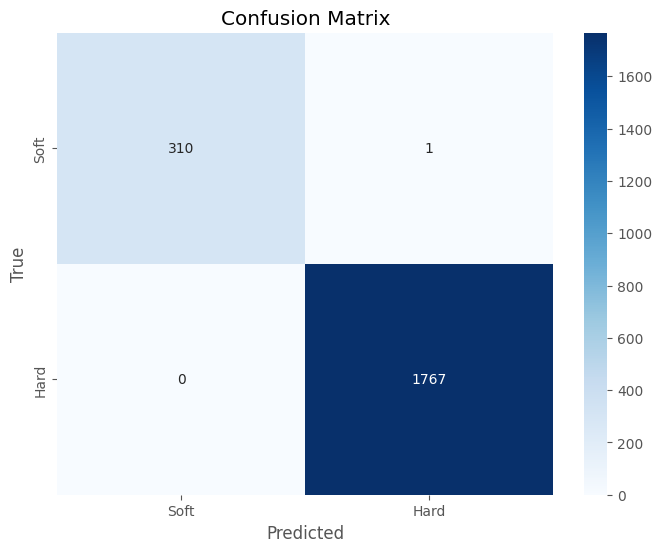

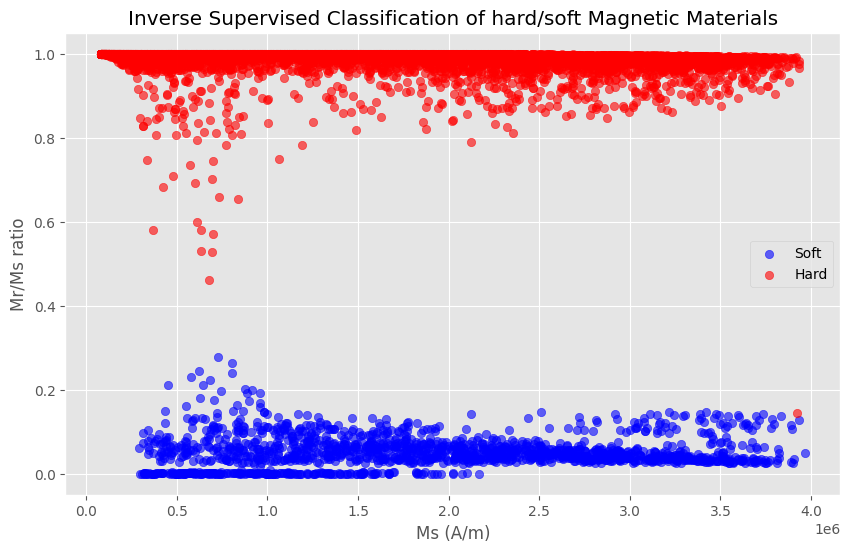


Supervised clustering results:
Number of soft magnets:  1555
Number of hard magnets:  8833


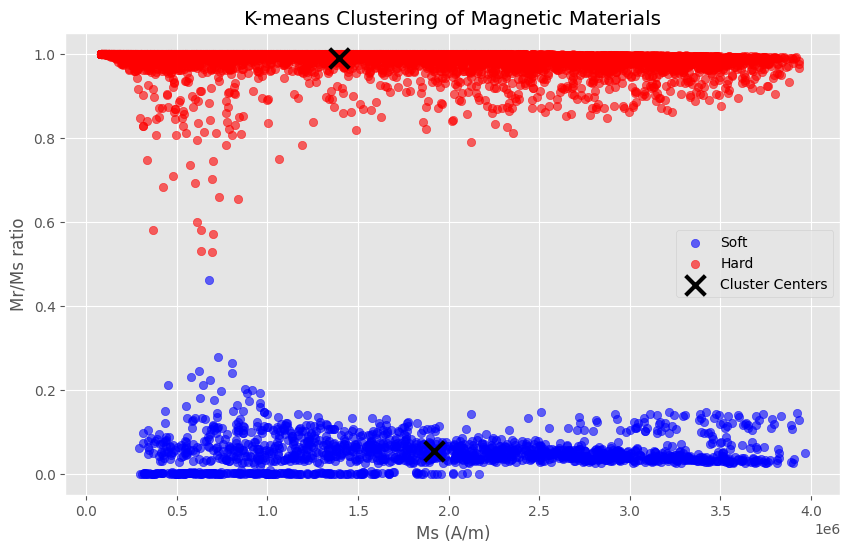


K-means clustering results:
Number of soft magnets:  1557
Number of hard magnets:  8831

Analysis complete. Please check the plots directory for visualizations.


In [14]:
analyze_magnetic_data(data_path='../data/single_grain_cube_50nm_aligned.csv')

## Training Data Generation
The training data had been created using the micromagnetic simulations with the [Mammos-Mumag package](https://github.com/MaMMoS-project/mammos-mumag) package. An isolated cubic grain with edge length 50nm has been simulated with aligned external magnetic field (H) and anisotropy axis (K1). One hysteresis loop was computed for each combination of material parameters A, Ms, K. From the hysteresis loops, Hc, Mr and BHmax are computed. The input ranges of the intrinsic properties were set to:

· 7.9×10^4 < Ms[A/m] < 3.9×10⁶ 

· 10⁻¹³ < A [J/m] < 10^-11

· 10⁴ < K1 [J/m³] < 10^7

This is the input data for the ML model, available at data/magnetic_materials.csv. In total 1497 data points were computed.


## Data Pre-Processing

Before model training, the variables of the dataset are analyzed and pre-processed. Histograms of all variables in the dataset are plotted and a pearson correlation analysis is performed among all variables. A classifier is trained to identify whether a material is a hard or a soft magnet (cluster0=soft magnet, cluster1=hard magnet).In particular, first a supervised classification algorithm is run which heuristically divides materials into hard and soft magnets based on a preset threshold of the Mr/Ms ratio. Subsequently, a K-means clustering algorithm is run to assign new unseen materials or test data into one of the material categories.  

Pre-processing:

- Remove rows with negative values in the chosen columns (optional).
- Convert values from A/m to Tesla for specified columns (optional)
- Apply a log transform to specified columns, except for the ones in log_exclude_cols.
- The pre-processing steps and models to train are specified in the configuration file (config/ml_config_test.yaml).

## Model training
The below code runs the machine learning pipeline of pre-processing the data, model training and evaluation.


Namely, a linear regression (LR) model, a random forest (RF), the LASSO regression, a Gaussian process and a fully connected neural network (FCNN) are fitted. Note that separate regressors have been trained for the hard and soft magnetic materials.

In [3]:
from scripts.train_model import MLPipeline
import argparse

In [ ]:
configpath = '../config/ml_config_test.yaml'

In [ ]:
pipeline = MLPipeline(configpath)

In [ ]:
pipeline.run()

# Plot Metrics
Observed versus fitted plots and tables containing the metric results are generated with the below code snippet and stored under 'results/plots/' and 'results/metric_tables/'. Model weights are stored under 'results/models/'.

In [4]:
from scripts.plot_metrics import *

In [5]:
results_dir = '../results/'

In [6]:
output = '../results/metric_tables'

In [7]:
# Set matplotlib style
plt.style.use('ggplot')

In [8]:
# Set default output directory as a subdirectory of the input directory
results_path = Path(results_dir)
if output is None:
    output_path = results_path / "metric_tables"
else:
    output_path = Path(output)

In [9]:
# Create output directory
output_path.mkdir(parents=True, exist_ok=True)

In [10]:
# Load results
results = load_results(results_dir)

In [11]:
# Create tables
create_metric_tables(results, output_path)
        
print(f"Tables and plots generated successfully in {output_path}")

Saved metrics plot to ../results/metric_tables/LogTransformation_all_standard_Overall_metrics.png
Saved metrics plot to ../results/metric_tables/LogTransformation_all_standard_Ms__A_m__metrics.png
Saved metrics plot to ../results/metric_tables/LogTransformation_all_standard_A__J_m__metrics.png
Saved metrics plot to ../results/metric_tables/LogTransformation_all_standard_K__J_m_3__metrics.png
Saved metrics plot to ../results/metric_tables/LogTransformation_cluster0_standard_Overall_metrics.png
Saved metrics plot to ../results/metric_tables/LogTransformation_cluster0_standard_Ms__A_m__metrics.png
Saved metrics plot to ../results/metric_tables/LogTransformation_cluster0_standard_A__J_m__metrics.png
Saved metrics plot to ../results/metric_tables/LogTransformation_cluster0_standard_K__J_m_3__metrics.png
Saved metrics plot to ../results/metric_tables/LogTransformation_cluster1_standard_Overall_metrics.png
Saved metrics plot to ../results/metric_tables/LogTransformation_cluster1_standard_Ms__